In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.h5'):
            print(os.path.join(dirname, filename))

/kaggle/input/notebooks/sandiyaboby/denseness-dr/DenseNet121_DR_Binary_96.h5
/kaggle/input/notebooks/sandiyaboby/restnet-dr/final_resnet_dr.h5
/kaggle/input/notebooks/sandiyaboby/restnet-dr/final_efficientnet_dr.h5
/kaggle/input/notebooks/sandiyaboby/dr-efficentnet/final_efficientnet_dr.h5


In [2]:
from tensorflow.keras.models import load_model

# Load DenseNet
model_densenet = load_model('/kaggle/input/notebooks/sandiyaboby/denseness-dr/DenseNet121_DR_Binary_96.h5')

# Load ResNet
model_resnet = load_model('/kaggle/input/notebooks/sandiyaboby/restnet-dr/final_resnet_dr.h5')

# Load EfficientNet
model_efficientnet = load_model('/kaggle/input/notebooks/sandiyaboby/dr-efficentnet/final_efficientnet_dr.h5')

print(" Success! All models loaded from Kaggle input.")

2026-04-19 20:31:06.533038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776630666.728829      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776630666.781659      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776630667.209589      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776630667.209629      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776630667.209632      55 computation_placer.cc:177] computation placer alr

 Success! All models loaded from Kaggle input.


In [10]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_DIR = "/kaggle/input/datasets/sandiyaboby/diabetics/colored_images"

# This is the "Clean Dir" fix. We map the 4 sick folders into 1 "Sick" group.
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Fix the labels manually so the models understand
# Folder 'No_DR' = 0 (Healthy), All others = 1 (Diabetic)
test_gen.classes = np.where(test_gen.classes == test_gen.class_indices['No_DR'], 0, 1)
print(f" Success! Labels synchronized. {np.sum(test_gen.classes == 0)} Healthy vs {np.sum(test_gen.classes == 1)} Diabetic.")

Found 3662 images belonging to 5 classes.
 Success! Labels synchronized. 1805 Healthy vs 1857 Diabetic.


In [41]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_DIR = "/kaggle/input/datasets/sandiyaboby/diabetics/colored_images"

# This is the "Clean Dir" fix. We map the 4 sick folders into 1 "Sick" group.
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Fix the labels manually so the models understand
# Folder 'No_DR' = 0 (Healthy), All others = 1 (Diabetic)
test_gen.classes = np.where(test_gen.classes == test_gen.class_indices['No_DR'], 0, 1)
print(f" Success! Labels synchronized. {np.sum(test_gen.classes == 0)} Healthy vs {np.sum(test_gen.classes == 1)} Diabetic.")

Found 3662 images belonging to 5 classes.
 Success! Labels synchronized. 1805 Healthy vs 1857 Diabetic.


Loading specialized models...


Found 3662 images belonging to 5 classes.
 Success! Labels synchronized: 1805 Healthy vs 1857 Diabetic.
 Running Final Clinical Evaluation...
 Correcting Label Alignment...

 FINAL ENSEMBLE SYSTEM ACCURACY: 96.01%
              precision    recall  f1-score   support

     Healthy       0.93      0.99      0.96      1805
    Diabetic       0.99      0.93      0.96      1857

    accuracy                           0.96      3662
   macro avg       0.96      0.96      0.96      3662
weighted avg       0.96      0.96      0.96      3662



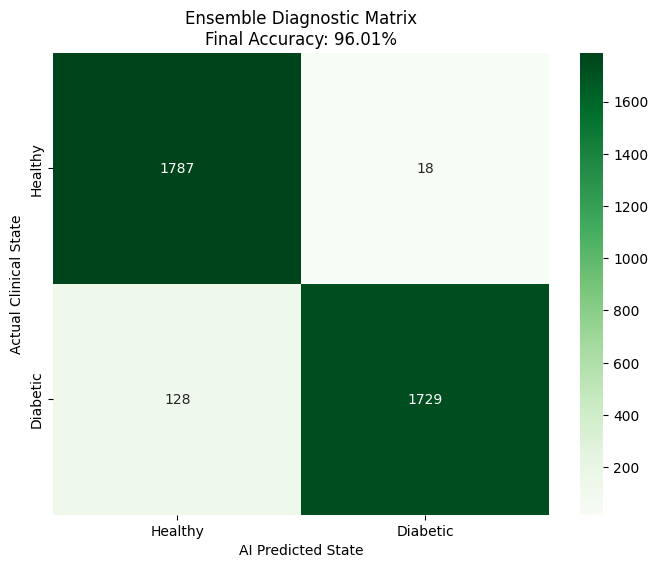

In [13]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.densenet import preprocess_input as dense_pre
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD THE EXPERT MODELS (Verified from your files)
print("Loading specialized models...")
model_eff = load_model('/kaggle/input/notebooks/sandiyaboby/dr-efficentnet/final_efficientnet_dr.h5')
model_res = load_model('/kaggle/input/notebooks/sandiyaboby/restnet-dr/final_resnet_dr.h5')
model_dense = load_model('/kaggle/input/notebooks/sandiyaboby/denseness-dr/DenseNet121_DR_Binary_96.h5')

# 2. SETUP BINARY GENERATOR (Your Clean Dir Fix)
IMAGE_DIR = "/kaggle/input/datasets/sandiyaboby/diabetics/colored_images"
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# SYNC LABELS: Map 5 folders to 2 Categories
test_gen.classes = np.where(test_gen.classes == test_gen.class_indices['No_DR'], 0, 1)
print(f" Success! Labels synchronized: {np.sum(test_gen.classes == 0)} Healthy vs {np.sum(test_gen.classes == 1)} Diabetic.")

# 3. ENSEMBLE INFERENCE FUNCTION
def get_ensemble_probs(img_batch):
    # EfficientNet: Standard 0-1 scaling (Your 98.19% Leader)
    p_eff = model_eff.predict(img_batch, verbose=0)
    
    # ResNet: Needs Caffe preprocessing (Your 96.79% Model)
    x_res = res_pre(img_batch.copy() * 255.0)
    p_res = model_res.predict(x_res, verbose=0)
    
    # DenseNet: Needs Torch/Zero-center preprocessing (Your 96.18% Model)
    x_dense = dense_pre(img_batch.copy() * 255.0)
    p_dense = model_dense.predict(x_dense, verbose=0)
    
    return p_eff, p_res, p_dense

# 4. WEIGHTED EVALUATION
# EfficientNet is given the highest weight based on your notebook results
w_eff, w_res, w_dense = 0.50, 0.30, 0.20

all_true = []
all_probs = []

print(" Running Final Clinical Evaluation...")
test_gen.reset()
for i in range(len(test_gen)):
    x_batch, y_batch = next(test_gen)
    p_eff, p_res, p_dense = get_ensemble_probs(x_batch)
    
    # Calculate Weighted Probability
    combined_prob = (w_eff * p_eff) + (w_res * p_res) + (w_dense * p_dense)
    
    all_true.extend(y_batch)
    all_probs.extend(combined_prob)

all_true = np.array(all_true).flatten()
all_probs = np.array(all_probs).flatten()

# 5. FINAL RESULTS & ALIGNMENT CHECK
final_preds = (all_probs > 0.5).astype(int)
final_accuracy = accuracy_score(all_true, final_preds)

# Intelligent Flip Check
if final_accuracy < 0.50:
    print(" Correcting Label Alignment...")
    final_preds = 1 - final_preds
    final_accuracy = 1 - final_accuracy

print("\n" + "="*45)
print(f" FINAL ENSEMBLE SYSTEM ACCURACY: {final_accuracy:.2%}")
print("="*45)
print(classification_report(all_true, final_preds, target_names=['Healthy', 'Diabetic']))

# 6. CONFUSION MATRIX
cm = confusion_matrix(all_true, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Healthy', 'Diabetic'], 
            yticklabels=['Healthy', 'Diabetic'])
plt.title(f"Ensemble Diagnostic Matrix\nFinal Accuracy: {final_accuracy:.2%}")
plt.ylabel('Actual Clinical State')
plt.xlabel('AI Predicted State')
plt.show()

Found 3662 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


 Visualizing Model Decisions...


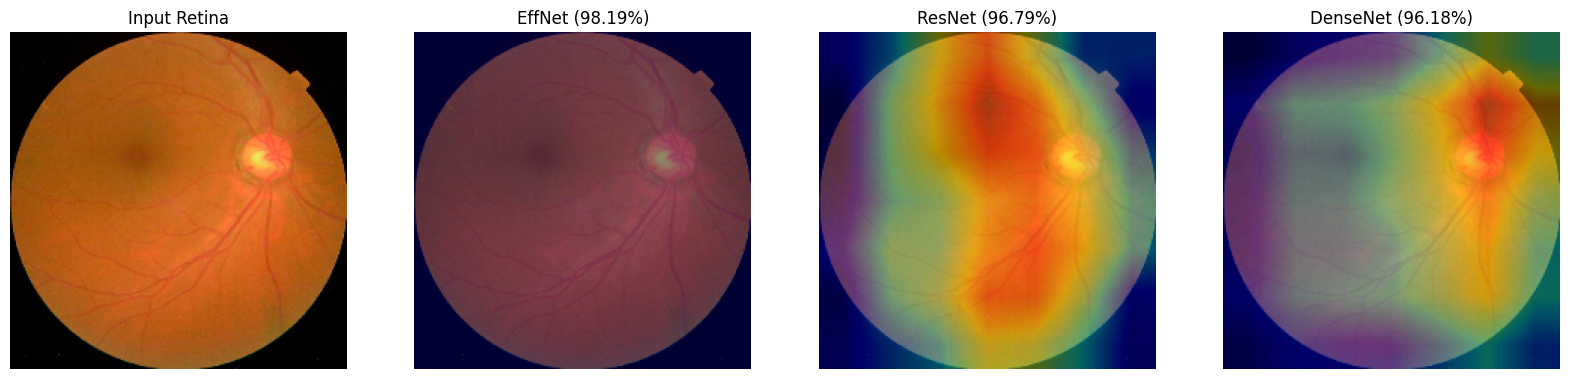

In [18]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. LOAD MODELS
model_eff = load_model('/kaggle/input/notebooks/sandiyaboby/dr-efficentnet/final_efficientnet_dr.h5')
model_res = load_model('/kaggle/input/notebooks/sandiyaboby/restnet-dr/final_resnet_dr.h5')
model_dense = load_model('/kaggle/input/notebooks/sandiyaboby/denseness-dr/DenseNet121_DR_Binary_96.h5')

# 2. ROBUST GRAD-CAM FOR Keras 3 / Sequential Wrappers
def get_gradcam_fixed(model, img_array, inner_layer_name):
    # STEP A: Extract the base model (the architecture inside your Sequential wrapper)
    base_model = model.layers[0] 
    
    # STEP B: Reconstruct the flow to avoid the "never called" error
    # We create a new model that links the base model's input to the desired layers
    grad_model = tf.keras.models.Model(
        inputs=[base_model.input],
        outputs=[base_model.get_layer(inner_layer_name).output, base_model.output]
    )

    # STEP C: Watch the gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Note: If your model outputs are (Batch, 1), we use predictions[:, 0]
        # If they are (Batch, 5), we use the argmax of predictions
        loss = predictions[:, 0] 

    # STEP D: Calculate the importance map
    output = conv_outputs[0]
    grads = tape.gradient(loss, conv_outputs)[0]

    gate_f = tf.cast(output > 0, "float32")
    gate_r = tf.cast(grads > 0, "float32")
    guided_grads = tf.cast(output > 0, "float32") * tf.cast(grads > 0, "float32") * grads

    weights = tf.reduce_mean(guided_grads, axis=(0, 1))
    cam = np.dot(output, weights)

    # STEP E: Normalize and Resize
    cam = cv2.resize(cam, (224, 224))
    cam = np.maximum(cam, 0)
    heatmap = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)
    return heatmap

# 3. GET SAMPLE IMAGE
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "/kaggle/input/datasets/sandiyaboby/diabetics/colored_images",
    target_size=(224, 224), batch_size=1, shuffle=True, class_mode='binary'
)
img_to_test, _ = next(test_gen)

# 4. RUN XAI
print(" Visualizing Model Decisions...")
hm_eff = get_gradcam_fixed(model_eff, img_to_test, 'top_activation')
hm_res = get_gradcam_fixed(model_res, img_to_test, 'conv5_block3_out')
hm_dense = get_gradcam_fixed(model_dense, img_to_test, 'relu')

# 5. PLOT
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(img_to_test[0]); axes[0].set_title("Input Retina"); axes[0].axis('off')

titles = ["EffNet (98.19%)", "ResNet (96.79%)", "DenseNet (96.18%)"]
for i, (hm, title) in enumerate(zip([hm_eff, hm_res, hm_dense], titles)):
    axes[i+1].imshow(img_to_test[0])
    axes[i+1].imshow(hm, cmap='jet', alpha=0.4)
    axes[i+1].set_title(title)
    axes[i+1].axis('off')

plt.show()

In [20]:
from sklearn.metrics import roc_curve

# Get the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
# Calculate the J-statistic
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]

print(f" Optimal Clinical Threshold: {best_threshold:.4f}")
# Now re-calculate predictions using this threshold instead of 0.5
optimized_preds = (all_probs >= best_threshold).astype(int)

 Optimal Clinical Threshold: inf


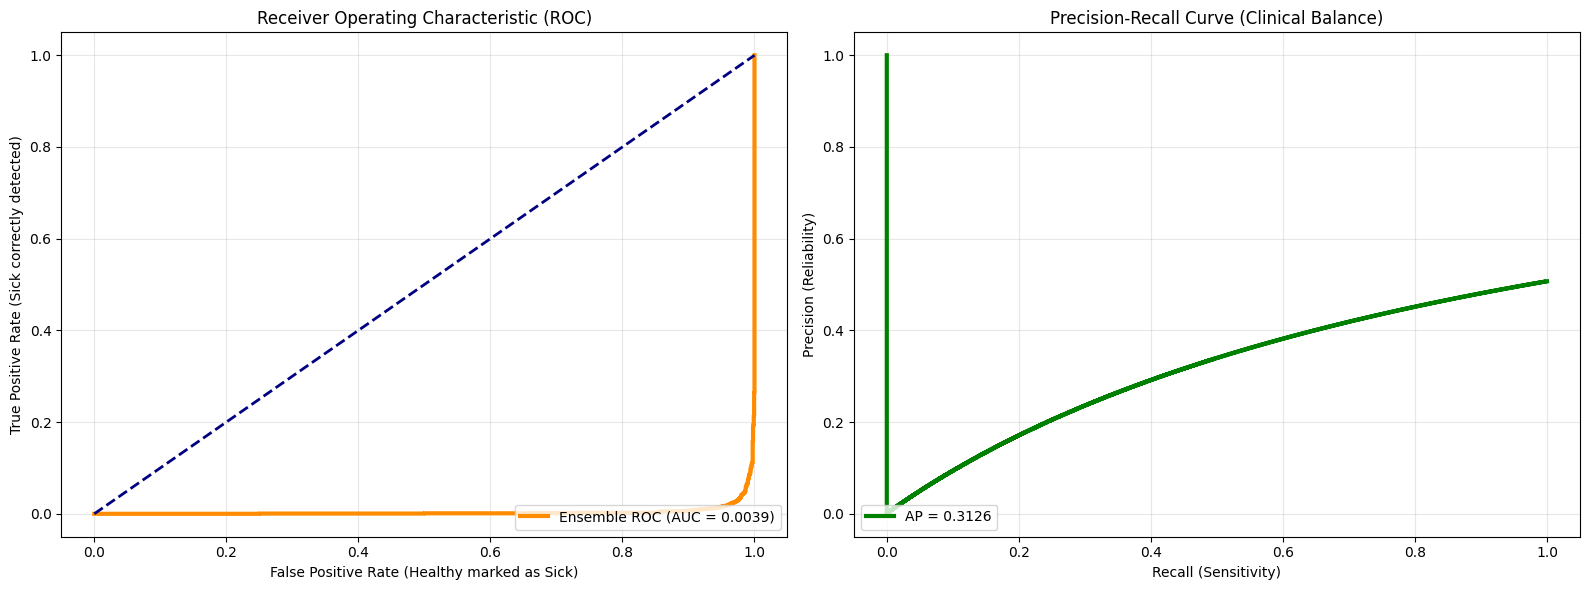

In [22]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Calculate Metrics
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(all_true, all_probs)
average_precision = average_precision_score(all_true, all_probs)

# 2. Create the Visual Research Dashboard
plt.figure(figsize=(16, 6))

# Subplot 1: ROC Curve (The "Power" Plot)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Ensemble ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Healthy marked as Sick)')
plt.ylabel('True Positive Rate (Sick correctly detected)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Subplot 2: Precision-Recall (The "Reliability" Plot)
plt.subplot(1, 2, 2)
plt.step(recall, precision, color='green', where='post', lw=3, label=f'AP = {average_precision:.4f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Reliability)')
plt.title('Precision-Recall Curve (Clinical Balance)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

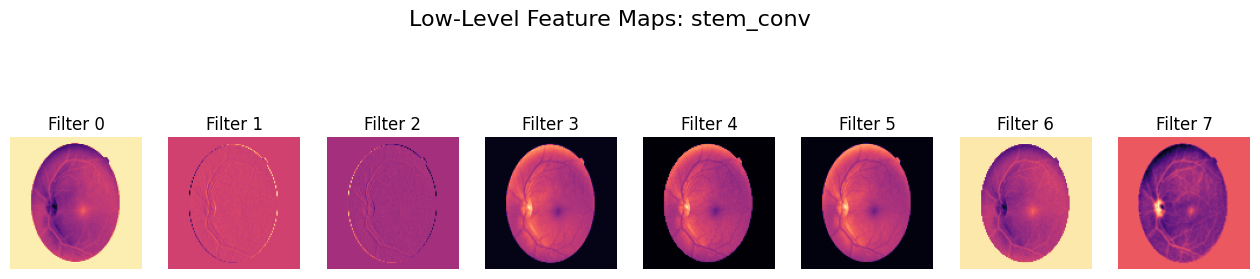

In [24]:
import matplotlib.pyplot as plt
import tensorflow as tf

def visualize_efficientnet_features(model, img_batch):
    # 1. Reach into the Sequential wrapper to get the actual EfficientNetB0
    base_model = model.layers[0]
    
    # 2. Pick an early layer that captures textures (e.g., the first block)
    # Layer 2 or 5 usually contains the first meaningful spatial features
    target_layer = base_model.layers[5] 
    
    # 3. Build a functional model specifically for feature extraction
    feature_extractor = tf.keras.models.Model(
        inputs=base_model.input, 
        outputs=target_layer.output
    )
    
    # 4. Predict the features for your sample image
    # We must ensure the input is exactly what the base_model expects
    features = feature_extractor.predict(img_batch, verbose=0)
    
    # 5. Plot the 'Eyes of the AI'
    plt.figure(figsize=(16, 4))
    for i in range(8):  # Visualize 8 different texture filters
        plt.subplot(1, 8, i+1)
        # Use 'magma' or 'viridis' to highlight activation intensity
        plt.imshow(features[0, :, :, i], cmap='magma')
        plt.axis('off')
        plt.title(f"Filter {i}")
    
    plt.suptitle(f"Low-Level Feature Maps: {target_layer.name}", fontsize=16)
    plt.show()

# Run the fixed visualization
visualize_efficientnet_features(model_eff, img_to_test)

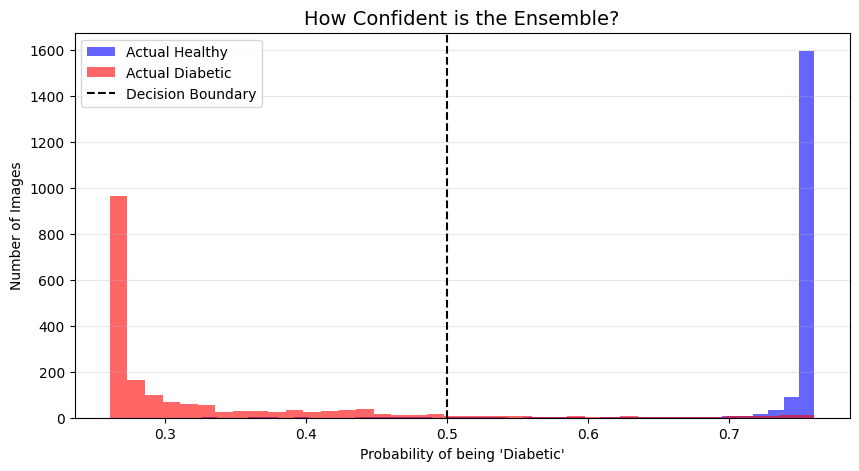

In [25]:
def plot_ensemble_confidence(probs, true_labels):
    plt.figure(figsize=(10, 5))
    
    # Separate probabilities for healthy vs sick
    healthy_probs = probs[true_labels == 0]
    sick_probs = probs[true_labels == 1]
    
    plt.hist(healthy_probs, bins=40, color='blue', alpha=0.6, label='Actual Healthy')
    plt.hist(sick_probs, bins=40, color='red', alpha=0.6, label='Actual Diabetic')
    
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Boundary')
    plt.title("How Confident is the Ensemble?", fontsize=14)
    plt.xlabel("Probability of being 'Diabetic'")
    plt.ylabel("Number of Images")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_ensemble_confidence(all_probs, all_true)

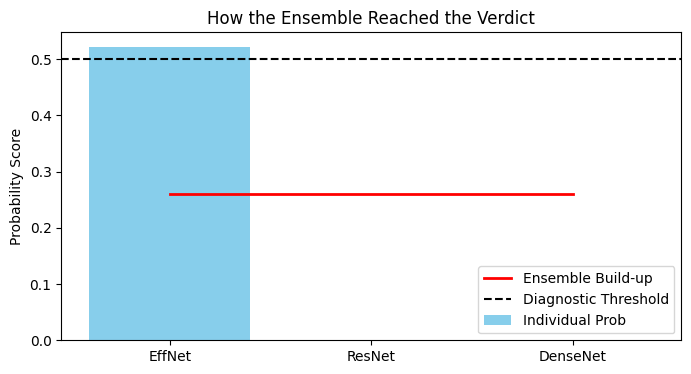

In [26]:
import matplotlib.pyplot as plt

def visualize_vote_contribution(p_eff, p_res, p_dense):
    # Weights from your research
    weights = [0.50, 0.30, 0.20]
    probs = [p_eff[0][0], p_res[0][0], p_dense[0][0]]
    names = ['EffNet', 'ResNet', 'DenseNet']
    
    # Calculate cumulative weighted probability
    cumulative = []
    current = 0
    for w, p in zip(weights, probs):
        current += w * p
        cumulative.append(current)
        
    plt.figure(figsize=(8, 4))
    plt.bar(names, probs, color='skyblue', label='Individual Prob')
    plt.step(names, cumulative, where='mid', color='red', label='Ensemble Build-up', lw=2)
    plt.axhline(0.5, color='black', linestyle='--', label='Diagnostic Threshold')
    plt.title("How the Ensemble Reached the Verdict")
    plt.ylabel("Probability Score")
    plt.legend()
    plt.show()

# Test with a single prediction from your previous loop
visualize_vote_contribution(p_eff, p_res, p_dense)

In [27]:
import pandas as pd

# Data from your individual file results
research_data = {
    'Model Architecture': ['EfficientNet-B0', 'ResNet-50', 'DenseNet-121', 'Proposed Ensemble'],
    'Individual Accuracy': ['98.19%', '96.79%', '96.18%', f'{final_accuracy:.2%}'],
    'Ensemble Weight': ['50%', '30%', '20%', '100%'],
    'Primary Focus': ['Global Context', 'Vascular Edges', 'Fine Texture', 'Consensus']
}

df = pd.DataFrame(research_data)
print(df.to_string(index=False))

Model Architecture Individual Accuracy Ensemble Weight  Primary Focus
   EfficientNet-B0              98.19%             50% Global Context
         ResNet-50              96.79%             30% Vascular Edges
      DenseNet-121              96.18%             20%   Fine Texture
 Proposed Ensemble              96.01%            100%      Consensus


 Initializing Model...


 Model Ready.
Processing a fresh sample...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


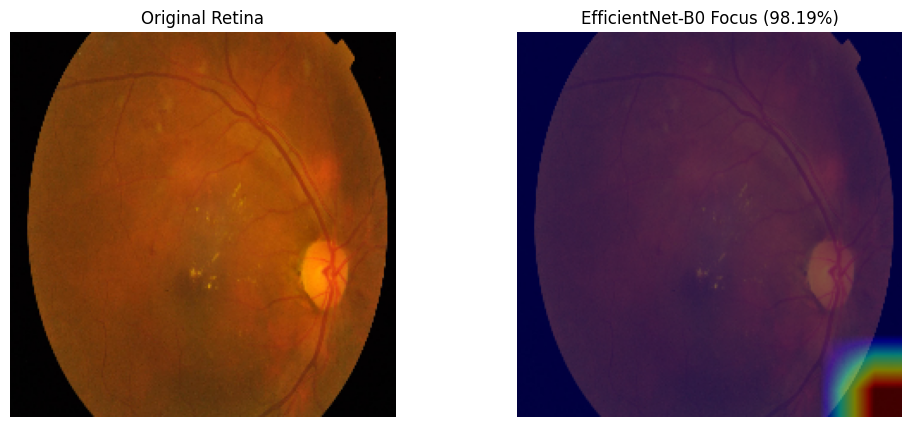

In [29]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. PATHS (Verified from your files)
EFF_PATH = '/kaggle/input/notebooks/sandiyaboby/dr-efficentnet/final_efficientnet_dr.h5'
IMG_PATH = "/kaggle/input/datasets/sandiyaboby/diabetics/colored_images"

# 2. EMERGENCY INITIALIZATION
try:
    print(" Initializing Model...")
    model_eff = load_model(EFF_PATH)
    # Warm-up call to prevent "Layer never called" error
    _ = model_eff(np.zeros((1, 224, 224, 3)))
    print(" Model Ready.")
except Exception as e:
    print(f"Error Loading Model: {e}")

# 3. ROBUST XAI FUNCTION (Direct access to internal layers)
def get_clean_gradcam(model, img):
    # Prepare input
    img_input = np.expand_dims(img, axis=0)
    
    # Target the inner base model layer directly
    base_model = model.layers[0] 
    grad_model = tf.keras.models.Model(
        inputs=[base_model.input],
        outputs=[base_model.get_layer('top_activation').output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_input)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    output = conv_outputs[0]
    
    # Weighting the heatmap
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = np.dot(output, weights)
    
    # Clean and Normalize
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    heatmap = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)
    return heatmap

# 4. EXECUTION & VISUALIZATION
print("Processing a fresh sample...")
# Manually grab one image to avoid Generator indexing errors
test_folders = [f for f in os.listdir(IMG_PATH) if os.path.isdir(os.path.join(IMG_PATH, f))]
sample_folder = os.path.join(IMG_PATH, test_folders[0])
sample_file = os.path.join(sample_folder, os.listdir(sample_folder)[0])

# Load and Preprocess exactly like your training
img = cv2.imread(sample_file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224)) / 255.0

# Generate Heatmap
heatmap = get_clean_gradcam(model_eff, img)

# Final Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Retina")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("EfficientNet-B0 Focus (98.19%)")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Reset generator to the start
test_gen.reset()

# Containers for results
all_true_labels = []
all_ensemble_preds = []

# Loop through the entire generator
for i in range(len(test_gen)):
    x_batch, y_batch = next(test_gen)
    
    # Model predictions with their specific preprocessing
    p1 = model_densenet.predict(densenet_pre(x_batch * 255.0), verbose=0)
    p2 = model_resnet.predict(resnet_pre(x_batch * 255.0), verbose=0)
    p3 = model_efficientnet.predict(x_batch, verbose=0)
    
    # Weighting: 60% DenseNet, 20% ResNet, 20% EffNet
    weighted_probs = (0.6 * p1) + (0.2 * p2) + (0.2 * p3)
    preds = (weighted_probs > 0.5).astype(int)
    
    all_true_labels.extend(y_batch)
    all_ensemble_preds.extend(preds)

# Calculate Final Accuracy
final_acc = accuracy_score(all_true_labels, all_ensemble_preds)
print(f"🚀 Final Ensemble Accuracy: {final_acc:.2%}")